In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
import tempfile

import scanpy as sc
import scib as scIB
import scvi
import torch
from rich import print
from scib_metrics.benchmark import Benchmarker

import pandas as pd
import anndata as ad
from mousipy import translate

import pickle
import numpy as np

In [5]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Global seed set to 0


Last run with scvi-tools version: 1.0.3

In [6]:
sc.set_figure_params(figsize=(4, 4))
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

## We load and format our datasets

### Flex

In [13]:
# we load our flex data
flex = sc.read("../data/260429-after-annotation-1.h5ad")

In [14]:
flex

AnnData object with n_obs × n_vars = 44566 × 17412
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample.id', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'cell_type'

In [15]:
flex.obs['sample.id'].value_counts()

sample.id
ht70             13043
ht67-cd205pos    12662
ht71             10703
ht67-cd205neg     8158
Name: count, dtype: int64

In [16]:
# we add batch information- batch 1 is protocol, batch 2 is donor, batch 3 is study
flex.obs['batch_1'] = "flex"
flex.obs['batch_2'] = flex.obs['sample.id'].str.split("-").str[0].str.upper()
flex.obs['batch_3'] = "flex"

In [17]:
flex.obs[['sample.id', 'batch_2']].value_counts()

sample.id      batch_2
ht70           HT70       13043
ht67-cd205pos  HT67       12662
ht71           HT71       10703
ht67-cd205neg  HT67        8158
Name: count, dtype: int64

In [18]:
# we format the cell_type metadata
flex.obs['celltype_level_1'] = flex.obs['cell_type'].copy()
flex.obs['celltype_level_2'] = flex.obs['cell_type'].copy()
flex.obs['celltype_level_3'] = flex.obs['cell_type'].copy()

In [19]:
print(flex.var_names)

Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'RNF223', 'C1orf159',
       ...
       'TMCO5A', 'AC025283.2', 'TMIGD1', 'C17orf78', 'LGALS7', 'C19orf85',
       'DUSP21', 'SPANXN5', 'ESX1', 'GPR119'],
      dtype='object', length=17412)

### inTECgrated

In [20]:
# we load the intecgrated dataset
intecgrated = sc.read("../data/human_integrated_dataset_for_pub.h5ad")

In [21]:
intecgrated

AnnData object with n_obs × n_vars = 126687 × 36187
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'species', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'study', 'batch', 'batch_1', 'batch_2', 'batch_3', '_scvi_batch', '_scvi_labels', 'leiden_round_3', 'leiden_round_3_sub', 'scanvi_leiden_second_int', 'was_park_mcTEC', 'was_ciliated', 'celltype_level_1', 'scanvi_leiden_first_int', 'celltype_level_4_round_4', 'celltype_level_4_round_3', 'scanvi_leiden_second_int_ionocyte', 'scanvi_leiden_all_cells', 'celltype_level_4_round_5', 'was_organogenesis', 'celltype_level_4_round_6', 'celltype_level_3', 'celltype_level_2

In [22]:
intecgrated.obs[['batch_2']].value_counts()

batch_2      
HT11             27381
Ht9              13993
Ht14             13466
fetal_19w        11899
dn_mteclo_e       6584
dn_mteclo_d       6134
HT13              6103
campinotti        5654
C40               5417
raggazzini        4316
dn_mteclo_c       4245
fetal_23w         3908
A43               3703
C41               3120
adult_25y         2824
HT8               2124
T07               2051
postnatal_10m     1900
A45               1043
F83                465
postnatal_6d       204
F21                 45
F38                 25
F30                 20
F22                 16
F67                 13
F45                 13
F64                 12
F41                  8
C34                  1
Name: count, dtype: int64

In [23]:
# we re-format the gene names
intecgrated.var_names = intecgrated.var_names.str.split(".").str[1]

### Endothelial cells

In [24]:
endo = sc.read("../data/human_datasets_scvi_integrated_protocol_individual_study_covariates_3000_all_genes_cluster_4.h5ad")

In [25]:
endo

AnnData object with n_obs × n_vars = 16060 × 37077
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'species', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'study', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'
    layers: 'counts'

In [26]:
endo_fewer_genes = sc.read("../data/human_datasets_scvi_integrated_protocol_individual_study_covariates_3000_cluster_4.h5ad")

In [27]:
if all(endo.obs_names == endo_fewer_genes.obs_names):
    endo.obs = endo_fewer_genes.obs.copy()

In [28]:
endo.obs[['batch_2']].value_counts()

batch_2      
adult_25y        6839
fetal_23w        3127
HT8              2147
fetal_19w        2103
postnatal_10m    1653
HT11              120
postnatal_6d       40
Ht9                18
HT13                7
campinotti          3
dn_mteclo_c         2
dn_mteclo_d         1
Name: count, dtype: int64

In [29]:
# we add celltype data
endo.obs['celltype_level_1'] = "endothelial"
endo.obs['celltype_level_2'] = "endothelial"
endo.obs['celltype_level_3'] = "endothelial"

In [30]:
# we re-format the gene names
endo.var_names = endo.var_names.str.split(".").str[1]

## We combine our data

In [31]:
print(set(flex.obs_names).intersection(set(intecgrated.obs_names)))
print(set(flex.obs_names).intersection(set(endo.obs_names)))
print(set(endo.obs_names).intersection(set(intecgrated.obs_names)))

set()

set()

set()

In [32]:
adata = ad.concat([intecgrated, endo, flex])

In [33]:
adata

AnnData object with n_obs × n_vars = 187313 × 16365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2'

In [34]:
adata_all_genes = adata.copy()

## Subset to flex and bautista only, with cells that have prior metadata, and re-run the integration

### Collate bautista prior celltypes

In [35]:
baut_prior_metadata = pd.read_csv("../data/bautista_published_raw_obs.csv",
                                 index_col = "Unnamed: 0")

In [36]:
baut_prior_metadata = baut_prior_metadata.rename(columns={'cell_types':'prior_celltype'}).copy()

In [37]:
baut_prior_metadata

,n_genes,percent_mito,n_counts,S_score,G2M_score,phase,leiden,leiden_plotter,prior_celltype,samples,orig.ident,nCount_RNA,nFeature_RNA,sample,age,protocol
ACTGATGGTCGGATCC,1048,0.026630,2516.0,-0.033964,0.069361,G2M,4,4,Endo-3 (venous),Fetal (23 weeks),SeuratProject,3245.999990,1699,fetal_23w_1,fetal_23w,10x_3p_v2
ACAAAGATCTGATTCT,1728,0.072594,4353.0,-0.172148,-0.046201,G1,1,1,Endo-1 (venous),Adult (25 yo),SeuratProject,5822.999717,2419,adult_25y,adult_25y,10x_3p_v3
TTGACTTAGTCTCAAC,1823,0.032172,4476.0,-0.110214,0.094574,G2M,4,4,Endo-3 (venous),Fetal (23 weeks),SeuratProject,7392.999983,3490,fetal_23w_2,fetal_23w,10x_3p_v2
TGTATTCTCGGCCGAT,1178,0.028355,3033.0,-0.093378,-0.137541,G1,4,4,Endo-3 (venous),Fetal (23 weeks),SeuratProject,4033.000100,1952,fetal_23w_1,fetal_23w,10x_3p_v2
TCAGCTCAGGGTCTCC,1435,0.019211,3956.0,0.035120,0.012052,S,6,6,Immune,Postnatal (10 months),SeuratProject,5436.999980,2348,postnatal_10m_1,postnatal_10m,10x_3p_v2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTGCGGAGTTAAGATG,899,0.013390,1643.0,0.321488,-0.099037,S,4,4,Endo-3 (venous),Fetal (19 weeks),SeuratProject,2231.999993,1421,fetal_19w,fetal_19w,10x_3p_v2
ATCACGACAGACCTGC,1030,0.051463,1982.0,-0.088408,-0.067834,G1,1,1,Endo-1 (venous),Adult (25 yo),SeuratProject,4615.999981,2342,adult_25y,adult_25y,10x_3p_v3
AGCATACGTCAGAATA,2252,0.024504,4285.0,-0.134477,-0.310604,G1,8,8,Epithelium-2,Postnatal (10 months),SeuratProject,6420.000000,3527,postnatal_10m_2,postnatal_10m,10x_3p_v2
AGCTACAAGCCACTCG,1586,0.074482,5451.0,-0.118295,-0.192017,G1,3,3,Pericytes,Adult (25 yo),SeuratProject,6801.000142,2082,adult_25y,adult_25y,10x_3p_v3


In [38]:
baut_prior_metadata_epi = pd.read_csv("../data/GSE147520_epithelial_cells_obs.csv",
                                     index_col="barcode")

In [39]:
baut_prior_metadata_epi = baut_prior_metadata_epi[baut_prior_metadata_epi.index.isin(baut_prior_metadata_epi.index.drop_duplicates(keep = False))].copy()

In [40]:
baut_prior_metadata_epi = baut_prior_metadata_epi.rename(columns = {"cell_types_epith": "prior_celltype"}).copy()

In [41]:
# remove duplicate cells from bigger dataframe
to_remove = list(set(baut_prior_metadata.index).intersection(baut_prior_metadata_epi.index))
baut_prior_metadata = baut_prior_metadata.drop(to_remove).copy()

In [42]:
# keep common columns
common_cols = list(set(baut_prior_metadata.columns).intersection(baut_prior_metadata_epi.columns))
baut_prior_metadata = baut_prior_metadata[common_cols].copy()
baut_prior_metadata_epi = baut_prior_metadata_epi[common_cols].copy()

In [43]:
# combine
baut_prior_all_meta = pd.concat([baut_prior_metadata, baut_prior_metadata_epi], axis = 0)

In [44]:
baut_prior_all_meta

,percent_mito,phase,n_counts,prior_celltype,leiden,leiden_plotter,n_genes,S_score,samples,G2M_score
ACTGATGGTCGGATCC,0.026630,G2M,2516.0,Endo-3 (venous),4,4,1048,-0.033964,Fetal (23 weeks),0.069361
ACAAAGATCTGATTCT,0.072594,G1,4353.0,Endo-1 (venous),1,1,1728,-0.172148,Adult (25 yo),-0.046201
TTGACTTAGTCTCAAC,0.032172,G2M,4476.0,Endo-3 (venous),4,4,1823,-0.110214,Fetal (23 weeks),0.094574
TGTATTCTCGGCCGAT,0.028355,G1,3033.0,Endo-3 (venous),4,4,1178,-0.093378,Fetal (23 weeks),-0.137541
TCAGCTCAGGGTCTCC,0.019211,S,3956.0,Immune,6,6,1435,0.035120,Postnatal (10 months),0.012052
...,...,...,...,...,...,...,...,...,...,...
TTTGGTTAGTGGATTA,0.081437,S,3954.0,mTEC lo,3,3,1414,0.007659,Adult (25 yo),-0.077672
TTTGGTTCAAGAGATT,0.079509,S,5622.0,Immature TEC,0,0,1719,0.042003,Adult (25 yo),-0.200818
TTTGGTTGTTTAGTCG,0.076909,G1,5578.0,Immature TEC,0,0,1722,-0.172034,Adult (25 yo),-0.015635
TTTGGTTTCCAGTGCG,0.091887,G1,4092.0,Immature TEC,0,0,1609,-0.106344,Adult (25 yo),-0.133167


### Add metadata to anndata objects

#### Subset to bautista

In [45]:
adata_baut_all_genes = adata_all_genes[adata_all_genes.obs['batch_3'].isin(['bautista'])]

In [46]:
adata_baut_all_genes

View of AnnData object with n_obs × n_vars = 34497 × 16365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2'

#### Put barcodes as index

In [47]:
adata_baut_all_genes.obs['cell_name'] = adata_baut_all_genes.obs.index.copy()

In [48]:
adata_baut_all_genes.obs_names = adata_baut_all_genes.obs.index.str.replace("bautista-","").str.split("_").str[0].str.split("-").str[0].copy()

#### Keep cells with prior metadata

In [49]:
to_keep = list(set(adata_baut_all_genes.obs.index.drop_duplicates(keep = False)).intersection(baut_prior_all_meta.index))

In [50]:
adata_baut_all_genes_prior_meta = adata_baut_all_genes[adata_baut_all_genes.obs_names.isin(to_keep)]

In [51]:
adata_baut_all_genes_prior_meta

View of AnnData object with n_obs × n_vars = 25305 × 16365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'cell_name'

#### Add prior metadata

In [52]:
adata_baut_all_genes_prior_meta.obs = pd.concat([adata_baut_all_genes_prior_meta.obs, baut_prior_all_meta[baut_prior_all_meta.index.isin(to_keep)]], axis = 1)

In [53]:
# replace index with cell names
adata_baut_all_genes_prior_meta.obs_names = adata_baut_all_genes_prior_meta.obs['cell_name'].copy()

#### Get flex data

In [54]:
adata_flex_all_genes = adata_all_genes[adata_all_genes.obs['batch_3'].isin(['flex'])]

In [55]:
adata_flex_all_genes.obs['prior_celltype'] = adata_flex_all_genes.obs['celltype_level_3'].copy()

#### Combine with bautista data

In [56]:
adata_flex_baut_all_genes = ad.concat([adata_baut_all_genes_prior_meta, adata_flex_all_genes])

In [57]:
adata_flex_baut_all_genes.obs[['prior_celltype', 'batch_3']].value_counts()

prior_celltype        batch_3 
cTEC                  flex        16573
mTEC I                flex        10839
Endo-1 (venous)       bautista     9989
COL4A6+ TEC           flex         6555
Nurse                 flex         5328
TD-TEC                flex         3335
cTEC lo               bautista     3031
Immature TEC          bautista     3010
cTEC hi               bautista     2709
mTEC lo               bautista     1886
mTEC II               flex         1699
Neuroendocrine        bautista      931
Endo-3 (venous)       bautista      696
Mesenchyme            bautista      670
Myoid                 bautista      491
Corneocyte-like mTEC  bautista      490
Epithelium-1          bautista      448
Pericytes             bautista      402
Endothelial           flex          237
Endo-2 (arterial)     bautista      214
Aire+ mTEC hi         bautista      203
Immune                bautista       82
Endo-4 (lymph.)       bautista       27
Red blood cells       bautista       12
Myelin+  

In [58]:
adata_flex_baut = adata_flex_baut_all_genes.copy()

In [59]:
adata_flex_baut

AnnData object with n_obs × n_vars = 69871 × 16365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'prior_celltype'

## We get highly variable genes

In [60]:
# select highly-variable genes
sc.pp.highly_variable_genes(
        adata_flex_baut,
        flavor="seurat_v3",
        n_top_genes=3000,
        subset=True
    )

In [61]:
adata_flex_baut_all_genes

AnnData object with n_obs × n_vars = 69871 × 16365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'prior_celltype'

In [62]:
adata_flex_baut

AnnData object with n_obs × n_vars = 69871 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'prior_celltype'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [63]:
adata_flex_baut = adata_flex_baut.copy()

In [65]:
adata_flex_baut

AnnData object with n_obs × n_vars = 69871 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'prior_celltype'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

#### We run the integration

In [66]:
scvi.model.SCVI.setup_anndata(adata_flex_baut,
                              #layer="counts",
                              categorical_covariate_keys= ["batch_1","batch_2", "batch_3"]
                             )

In [67]:
model_flex_baut = scvi.model.SCVI(adata_flex_baut, n_layers=2, n_latent=30, gene_likelihood="nb")

In [68]:
model_flex_baut.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 114/114: 100%|█| 114/114 [38:31<00:00, 14.32s/it, v_num=1, train_loss_step

`Trainer.fit` stopped: `max_epochs=114` reached.


Epoch 114/114: 100%|█| 114/114 [38:31<00:00, 20.28s/it, v_num=1, train_loss_step


In [69]:
SCVI_LATENT_KEY = "X_scVI"
adata_flex_baut.obsm[SCVI_LATENT_KEY] = model_flex_baut.get_latent_representation()

In [70]:
sc.pp.neighbors(adata_flex_baut, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_flex_baut)

In [71]:
SCVI_MDE_KEY = "X_scVI_MDE"
adata_flex_baut.obsm[SCVI_MDE_KEY] = scvi.model.utils.mde(adata_flex_baut.obsm[SCVI_LATENT_KEY])

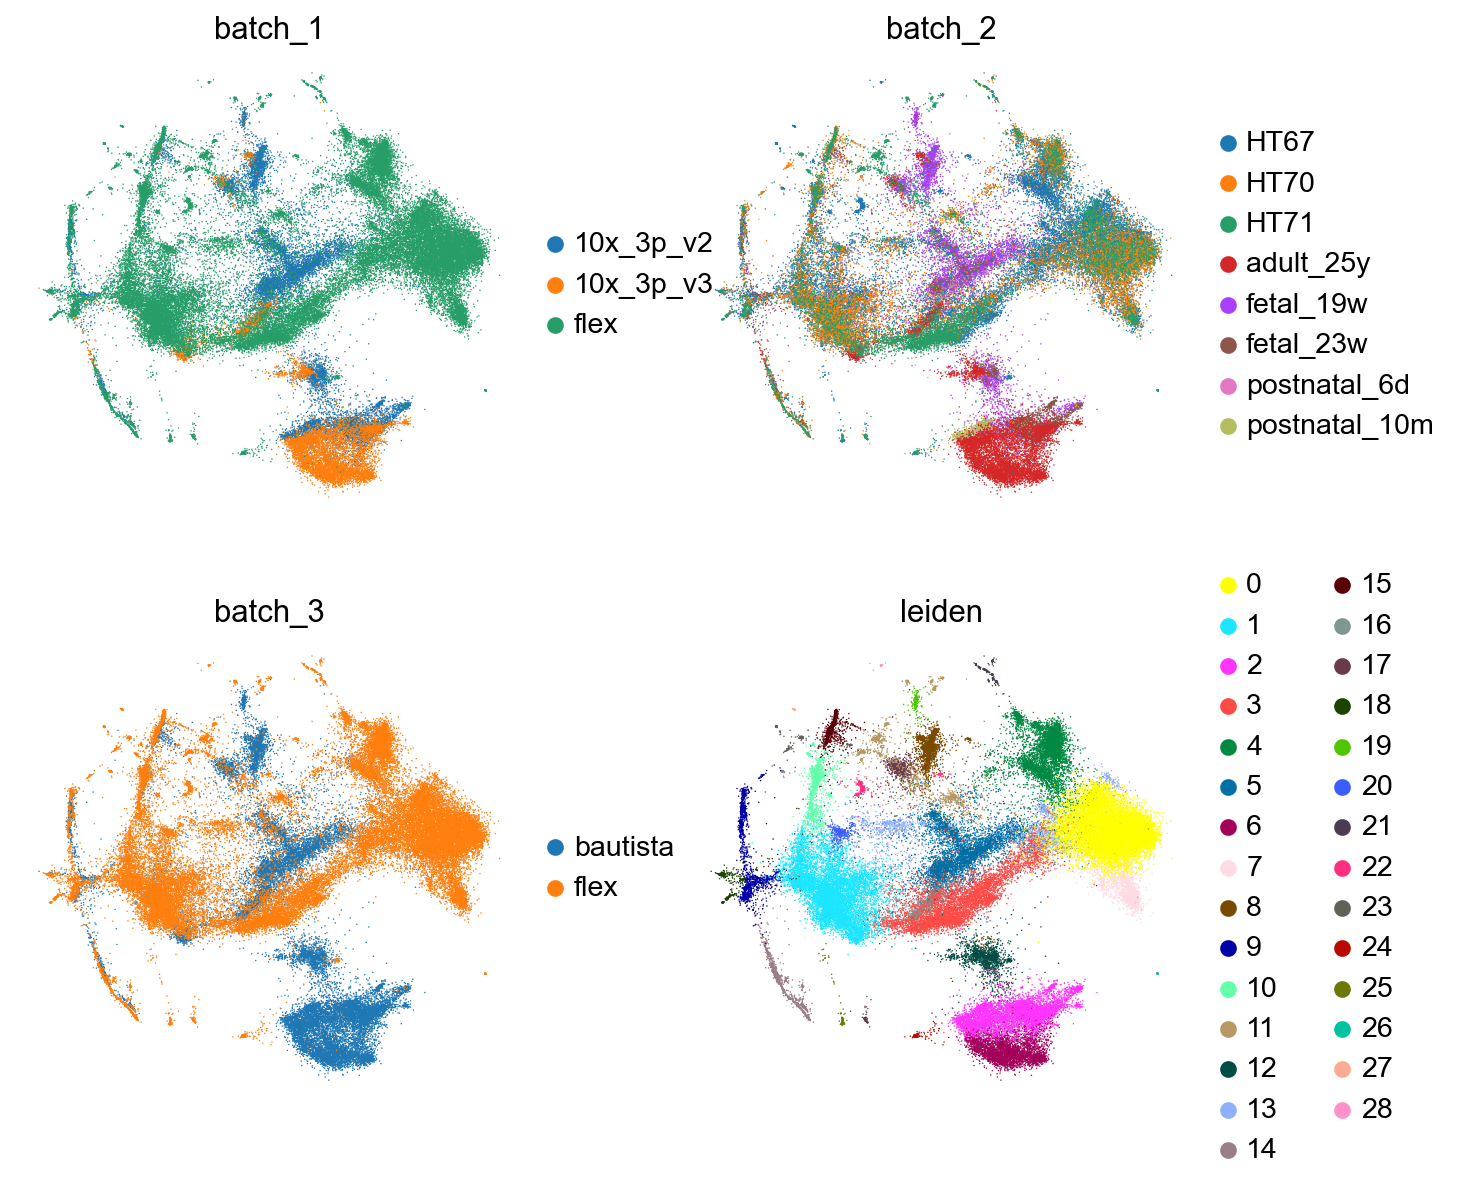

In [72]:
sc.pl.embedding(
    adata_flex_baut,
    basis=SCVI_MDE_KEY,
    color=["batch_1", "batch_2", "batch_3", "leiden"],
    frameon=False,
    ncols=2,
)

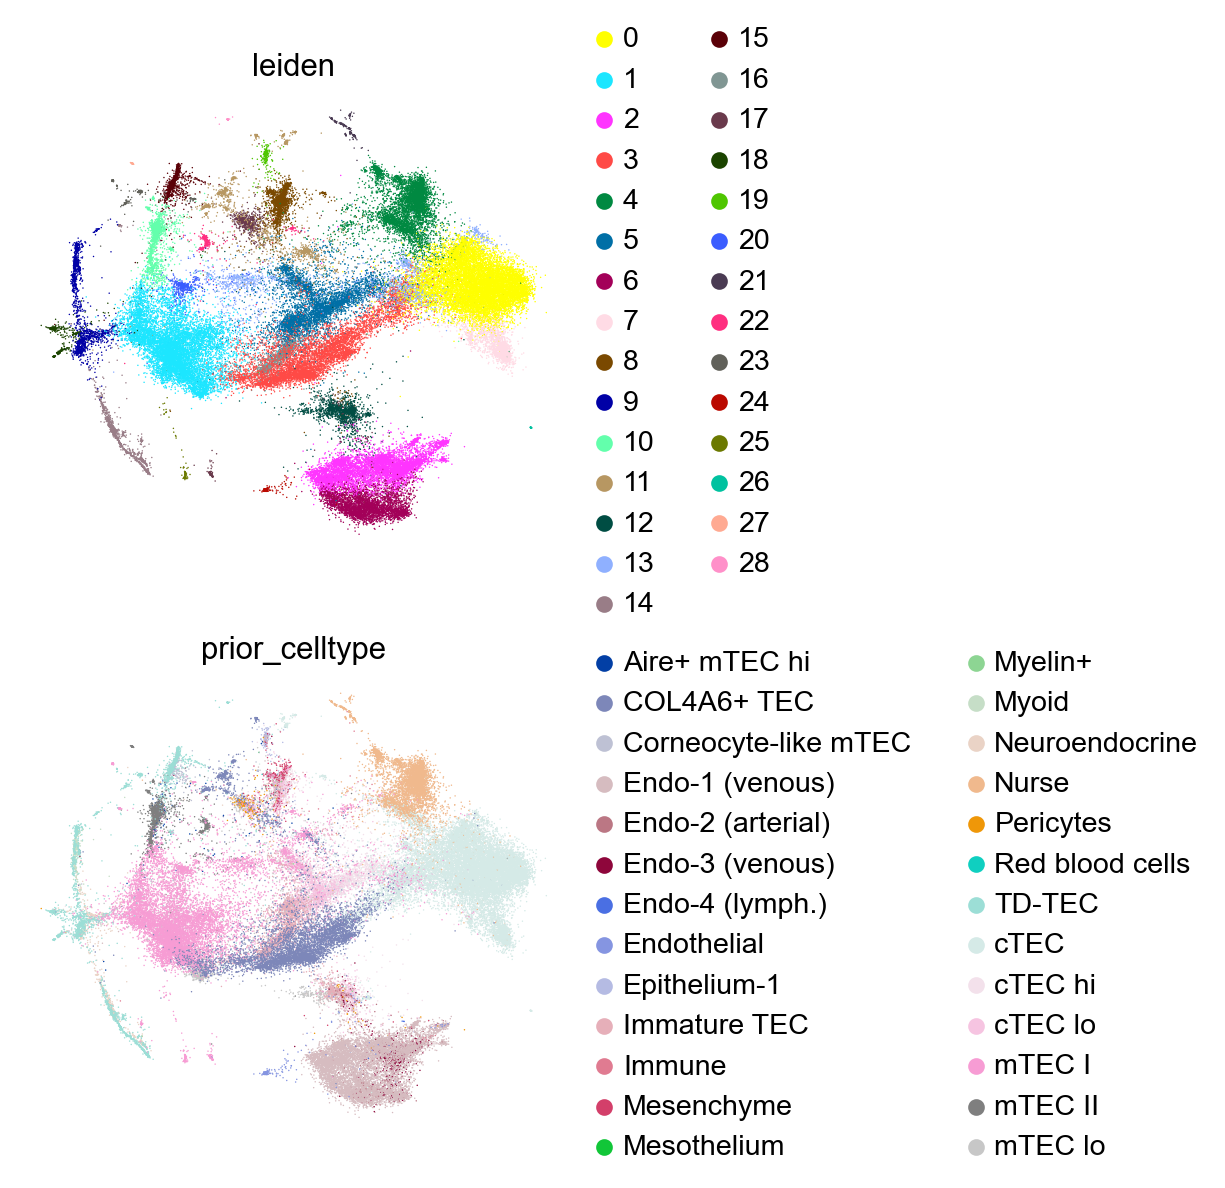

In [74]:
sc.pl.embedding(
    adata_flex_baut,
    basis=SCVI_MDE_KEY,
    color=["leiden", "prior_celltype"],
    frameon=False,
    ncols=1,
)

#### We save our integrated data so that we can run downstream analysis

In [75]:
adata_flex_baut.write_h5ad("baut_flex_scvi.h5ad")

In [76]:
import pickle
with open("baut_flex_scvi.pkl", 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(model_flex_baut, f, pickle.HIGHEST_PROTOCOL)

### Rename celltypes

In [77]:
adata_flex_baut.obs['celltype_updated'] = adata_flex_baut.obs['prior_celltype'].copy()

In [78]:
adata_flex_baut.obs['celltype_updated'].unique().tolist()

['Immature TEC',
 'cTEC lo',
 'Pericytes',
 'cTEC hi',
 'Red blood cells',
 'Endo-2 (arterial)',
 'mTEC lo',
 'Neuroendocrine',
 'Epithelium-1',
 'Endo-1 (venous)',
 'Aire+ mTEC hi',
 'Mesenchyme',
 'Corneocyte-like mTEC',
 'Endo-3 (venous)',
 'Immune',
 'Endo-4 (lymph.)',
 'Myoid',
 'Mesothelium',
 'Myelin+',
 'COL4A6+ TEC',
 'mTEC I',
 'mTEC II',
 'TD-TEC',
 'cTEC',
 'Nurse',
 'Endothelial']

In [79]:
replacement_dict = {
    "neuro": "mimetic",
    "neuroendocrine": "mimetic",
    "ionocyte": "mimetic",
    "transitioning": "mimetic",
    "muscle": "mimetic",
    "CCL21-positive TEC": "mTEC I",
    "heteroTEC": "mimetic",
    "tuft": "mimetic",
    "CFC1-positive cTEC": "cTEC",
    "ciliated": "mimetic",
    "COL4A6+ TEC": "BMC-TEC",
    "TD-TEC": "mimetic",
    "Nurse": "nurse",
    "Endothelial": "endothelial",
}

# Convert categorical column to object
adata_flex_baut.obs["celltype_updated"] = (
    adata_flex_baut.obs["celltype_updated"].astype(object)
)

# Only modify cells where batch_3 == "flex"
mask = adata_flex_baut.obs["batch_3"] == "flex"

adata_flex_baut.obs.loc[
    mask,
    "celltype_updated"
] = (
    adata_flex_baut.obs.loc[
        mask,
        "celltype_updated"
    ].replace(replacement_dict)
)

adata_flex_baut.obs["celltype_updated"] = (
    adata_flex_baut.obs["celltype_updated"].astype("category")
)

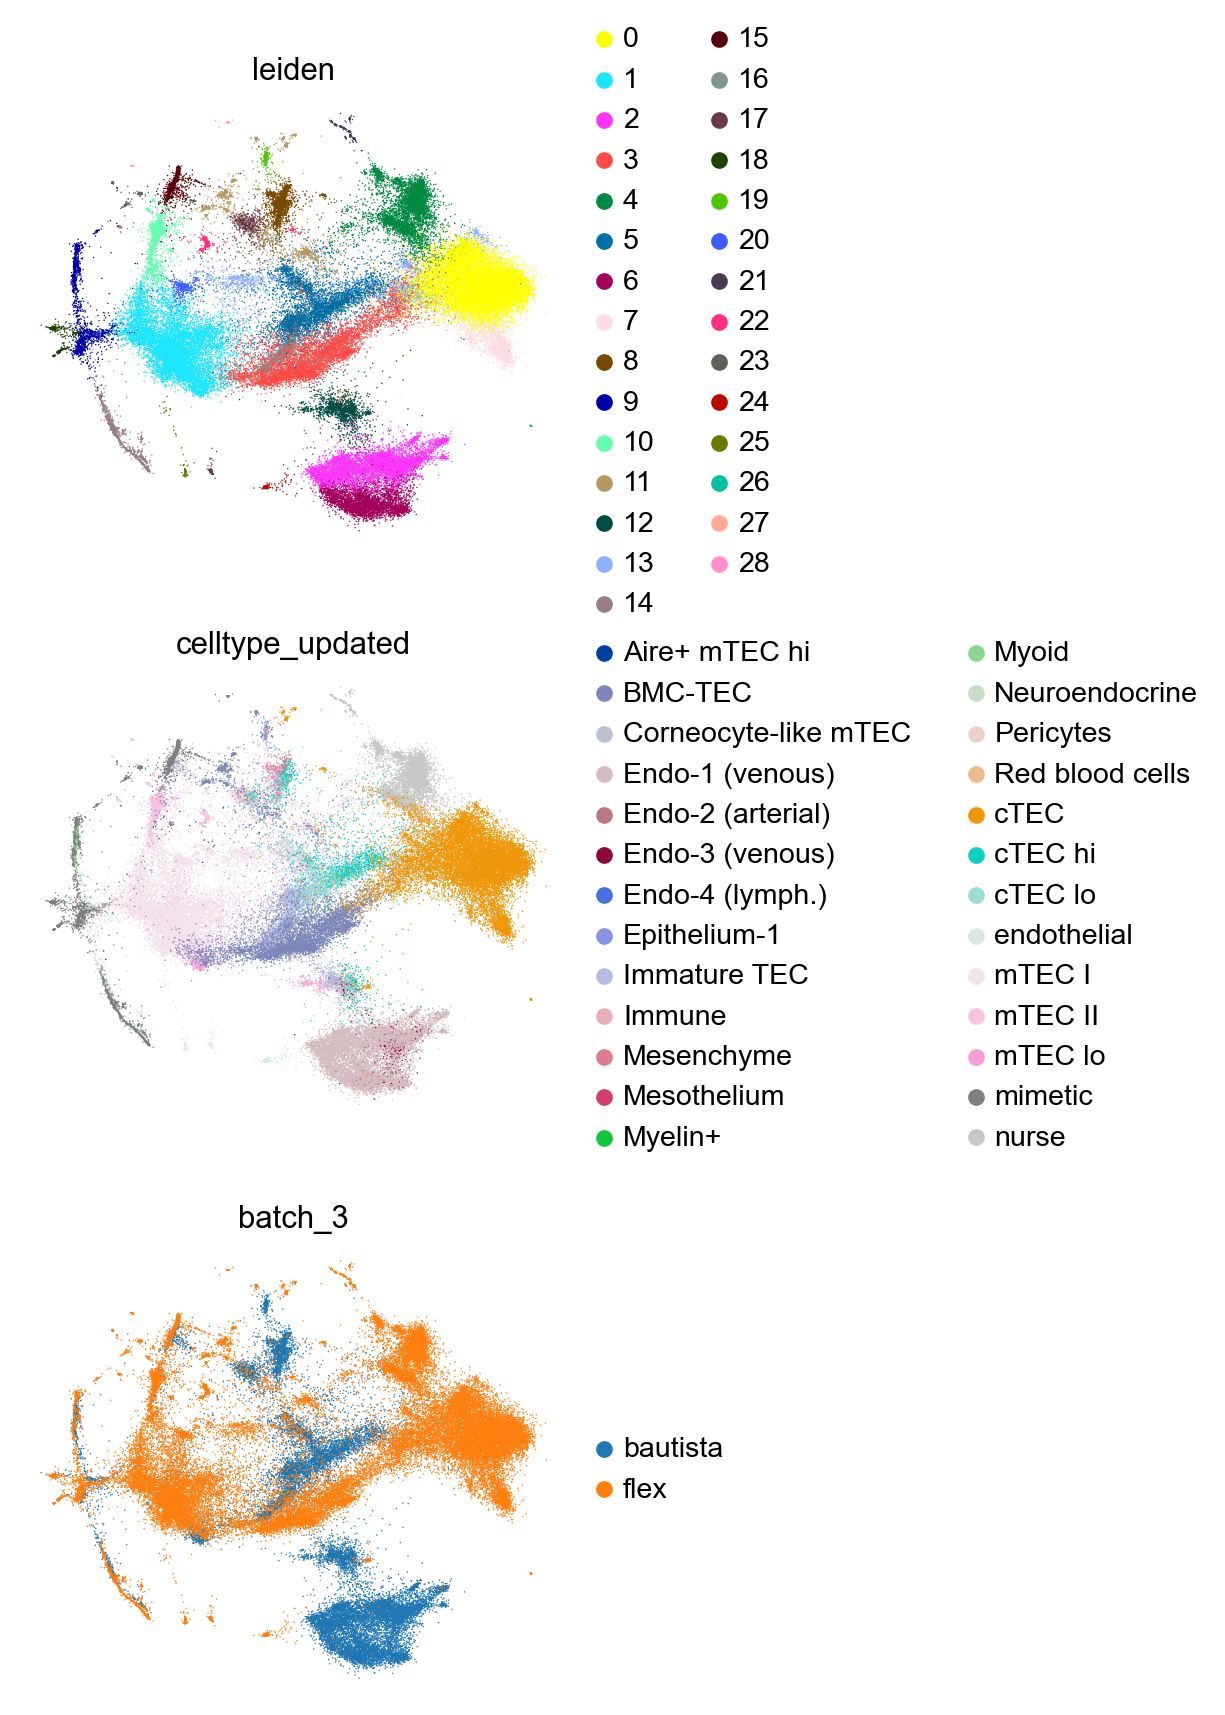

In [80]:
sc.pl.embedding(
    adata_flex_baut,
    basis=SCVI_MDE_KEY,
    color=["leiden", "celltype_updated", "batch_3"],
    frameon=False,
    ncols=1,
)

In [81]:
adata_flex_baut.write_h5ad("baut_flex_scvi.h5ad")

In [88]:
adata_flex_baut = sc.read("baut_flex_scvi.h5ad")

In [89]:
adata_flex_baut.obs['celltype_updated'].value_counts()

celltype_updated
cTEC                    16573
mTEC I                  10839
Endo-1 (venous)          9989
BMC-TEC                  6555
nurse                    5328
mimetic                  3335
cTEC lo                  3031
Immature TEC             3010
cTEC hi                  2709
mTEC lo                  1886
mTEC II                  1699
Neuroendocrine            931
Endo-3 (venous)           696
Mesenchyme                670
Myoid                     491
Corneocyte-like mTEC      490
Epithelium-1              448
Pericytes                 402
endothelial               237
Endo-2 (arterial)         214
Aire+ mTEC hi             203
Immune                     82
Endo-4 (lymph.)            27
Red blood cells            12
Myelin+                    10
Mesothelium                 4
Name: count, dtype: int64

In [90]:
replacement_dict = {
    "cTEC": "TEC",
    "mTEC I": "TEC",
    "mTEC lo": "TEC",
    "Endo-1 (venous)": "endothelial",
    "BMC-TEC": "TEC",
    "mimetic": "TEC",
    "cTEC lo": "TEC",
    "Immature TEC": "TEC",
    "cTEC hi": "TEC",
    "mTEC II": "TEC",
    "Neuroendocrine": "TEC",
    "Endo-3 (venous)": "endothelial",
    "Myoid": "TEC",
    "Corneocyte-like mTEC": "TEC",
    "Epithelium-1": "TEC",
    "Endo-2 (arterial)": "endothelial",
    "Aire+ mTEC hi": "TEC",
    "Endo-4 (lymph.)": "endothelial",
    "Myelin+": "TEC",
    "Mesenchyme": "mesenchyme",
    "Pericytes": "pericytes",
    "Immune": "immune",
    "Red blood cells": "red blood cells",
    "Mesothelium": "mesothelium",
}

# Convert to object so new category values can be assigned
adata_flex_baut.obs["celltype_updated"] = (
    adata_flex_baut.obs["celltype_updated"].astype(object)
)

# Replace values in the column
adata_flex_baut.obs["celltype_updated"] = (
    adata_flex_baut.obs["celltype_updated"].replace(replacement_dict)
)

# Convert back to categorical
adata_flex_baut.obs["celltype_updated"] = (
    adata_flex_baut.obs["celltype_updated"].astype("category")
)

In [91]:
adata_flex_baut.obs['celltype_updated'].value_counts()

celltype_updated
TEC                52210
endothelial        11163
nurse               5328
mesenchyme           670
pericytes            402
immune                82
red blood cells       12
mesothelium            4
Name: count, dtype: int64

### Evaluate cluster compositions

In [92]:
adata_flex_baut[adata_flex_baut.obs['batch_3'] == "flex"].obs[['celltype_updated', 'leiden']].value_counts().head(20)

celltype_updated  leiden
TEC               0         11662
                  1          7963
                  3          6042
nurse             4          4769
TEC               7          2201
                  10         1675
                  11         1619
                  13         1480
                  9          1112
                  14          898
                  15          698
                  4           648
                  5           528
                  20          474
                  18          465
nurse             21          378
TEC               22          348
                  23          328
endothelial       24          197
TEC               17          186
Name: count, dtype: int64

In [93]:
adata_flex_baut[adata_flex_baut.obs['batch_3'] != "flex"].obs[['celltype_updated', 'leiden']].value_counts().head(20)

celltype_updated  leiden
endothelial       2         6827
TEC               5         4737
endothelial       6         3760
TEC               8         1389
                  12        1162
                  1         1146
                  16        1082
                  9          761
mesenchyme        8          585
TEC               14         540
                  17         452
                  15         443
                  19         443
pericytes         17         357
endothelial       12         256
TEC               4          196
                  10         169
                  0          159
                  3          150
                  18          93
Name: count, dtype: int64

## Supervised integration

### We proceed with our integration by celltype

In [94]:
# load scvi model
import pickle
with open("baut_flex_scvi.pkl", "rb") as input_file:
    model_batch_flex_baut = pickle.load(input_file)

In [95]:
scanvi_model_batch_flex_baut = scvi.model.SCANVI.from_scvi_model(
    model_batch_flex_baut,
    adata=adata_flex_baut,
    labels_key="celltype_updated",
    unlabeled_category="unknown",
)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [96]:
scanvi_model_batch_flex_baut.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 20/20: 100%|█| 20/20 [07:46<00:00, 23.16s/it, v_num=1, train_loss_step=1.0

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|█| 20/20 [07:46<00:00, 23.33s/it, v_num=1, train_loss_step=1.0


In [97]:
SCANVI_LATENT_KEY = "X_scANVI"
adata_flex_baut.obsm[SCANVI_LATENT_KEY] = scanvi_model_batch_flex_baut.get_latent_representation(adata_flex_baut)

In [98]:
SCANVI_MDE_KEY = "X_scANVI_MDE"
adata_flex_baut.obsm[SCANVI_MDE_KEY] = scvi.model.utils.mde(adata_flex_baut.obsm[SCANVI_LATENT_KEY])

In [99]:
sc.pp.neighbors(adata_flex_baut, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_flex_baut, key_added= "scanvi_leiden")

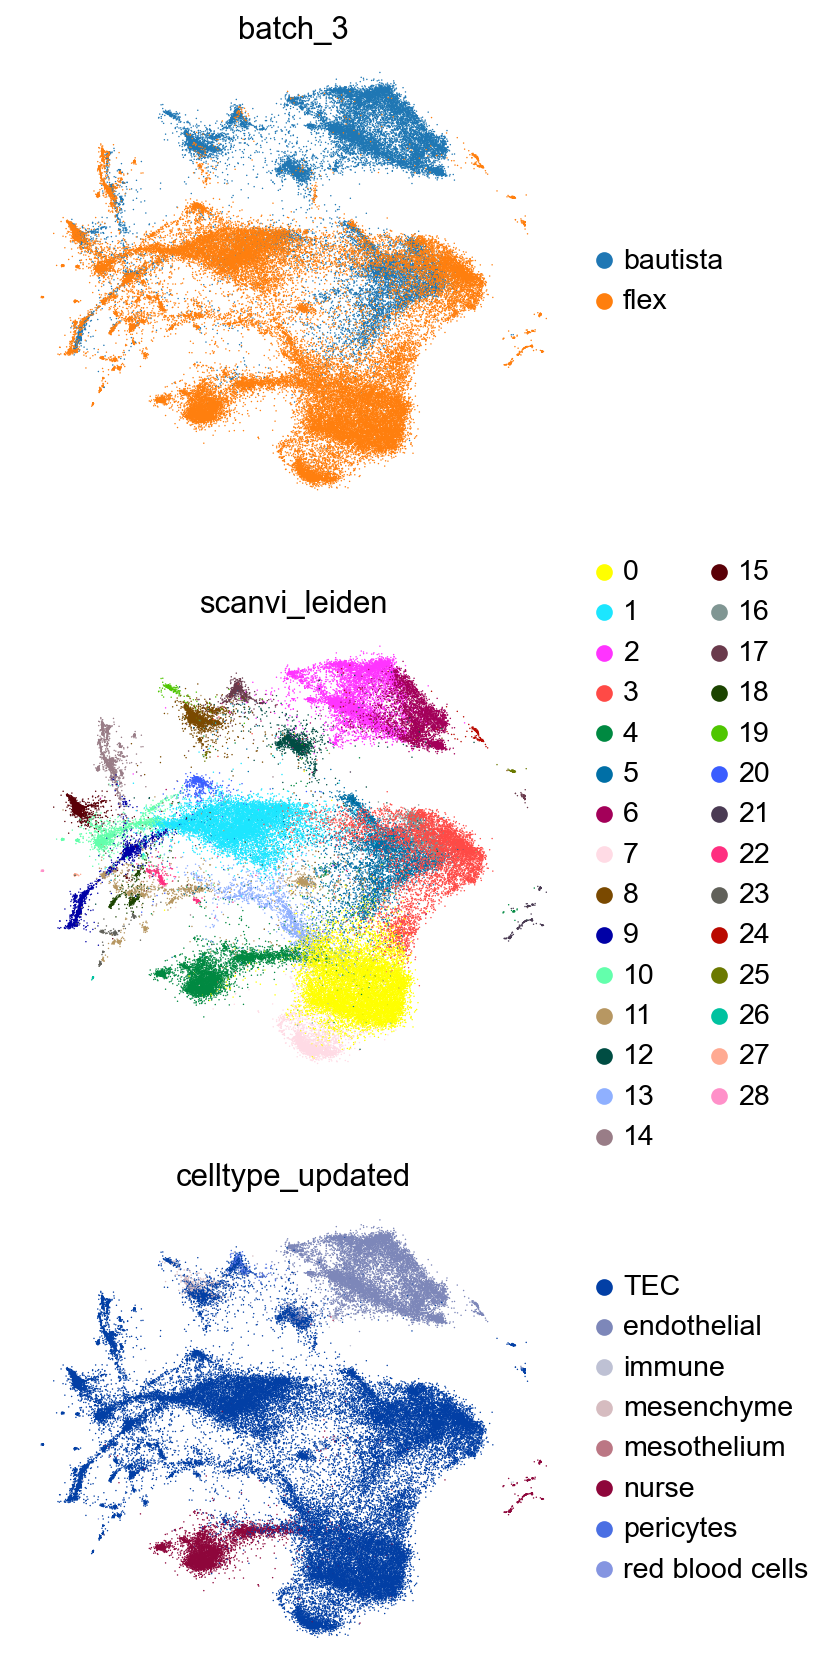

In [100]:
sc.pl.embedding(
    adata_flex_baut, basis=SCANVI_MDE_KEY, color=["batch_3", "scanvi_leiden", "celltype_updated"], ncols=1, frameon=False
)

In [104]:
adata_flex_baut[adata_flex_baut.obs['batch_3'] == "flex"].obs['celltype_updated'].value_counts()

celltype_updated
TEC            39001
nurse           5328
endothelial      237
Name: count, dtype: int64

In [105]:
adata_flex_baut[adata_flex_baut.obs['batch_3'] == "bautista"].obs['celltype_updated'].value_counts()

celltype_updated
TEC                13209
endothelial        10926
mesenchyme           670
pericytes            402
immune                82
red blood cells       12
mesothelium            4
Name: count, dtype: int64

In [106]:
adata_flex_baut.write_h5ad("baut_flex_scanvi.h5ad")

In [107]:
import pickle
with open("baut_flex_scanvi.pkl", 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(scanvi_model_batch_flex_baut, f, pickle.HIGHEST_PROTOCOL)

In [153]:
# load data
adata_flex_baut = sc.read("baut_flex_scanvi.h5ad")

In [154]:
adata_flex_baut

AnnData object with n_obs × n_vars = 69871 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch_1', 'batch_2', 'batch_3', 'celltype_level_1', 'celltype_level_3', 'celltype_level_2', 'prior_celltype', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_updated', 'scanvi_leiden'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_1_colors', 'batch_2_colors', 'batch_3_colors', 'celltype_updated_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'prior_celltype_colors', 'scanvi_leiden_colors'
    obsm: 'X_scANVI', 'X_scANVI_MDE', 'X_scVI', 'X_scVI_MDE', '_scvi_extra_categorical_covs'
    obsp: 'connectivities', 'distances'

In [155]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_MDE_KEY = "X_scANVI_MDE"

In [156]:
## add back granular celltype labels
adata_flex_baut.obs['celltype'] = adata_flex_baut.obs['prior_celltype'].copy()
adata_flex_baut.obs['celltype'] = adata_flex_baut.obs['celltype'].replace("COL4A6+ TEC", "BMC-TEC")

In [157]:
# fix names
replacement_dict = {
    "TD-TEC": "Mimetic",
    "mTEC I": "mTEC lo",
    "mTEC II": "mTEC hi"
}

# Convert categorical column to object
adata_flex_baut.obs["celltype"] = (
    adata_flex_baut.obs["celltype"].astype(object)
)

# Only modify cells where batch_3 == "flex"
mask = adata_flex_baut.obs["batch_3"] == "flex"

adata_flex_baut.obs.loc[
    mask,
    "celltype"
] = (
    adata_flex_baut.obs.loc[
        mask,
        "celltype"
    ].replace(replacement_dict)
)

adata_flex_baut.obs["celltype"] = (
    adata_flex_baut.obs["celltype"].astype("category")
)

In [158]:
print(adata_flex_baut.obs.celltype.unique()[0:10])
print(adata_flex_baut.obs.celltype.unique()[10:20])
print(adata_flex_baut.obs.celltype.unique()[20:30])

['Immature TEC', 'cTEC lo', 'Pericytes', 'cTEC hi', 'Red blood cells', 'Endo-2 (arterial)', 'mTEC lo', 
'Neuroendocrine', 'Epithelium-1', 'Endo-1 (venous)']
Categories (25, object): ['Aire+ mTEC hi', 'BMC-TEC', 'Corneocyte-like mTEC', 'Endo-1 (venous)', ..., 'cTEC hi', 
'cTEC lo', 'mTEC hi', 'mTEC lo']

['Aire+ mTEC hi', 'Mesenchyme', 'Corneocyte-like mTEC', 'Endo-3 (venous)', 'Immune', 'Endo-4 (lymph.)', 'Myoid', 
'Mesothelium', 'Myelin+', 'BMC-TEC']
Categories (25, object): ['Aire+ mTEC hi', 'BMC-TEC', 'Corneocyte-like mTEC', 'Endo-1 (venous)', ..., 'cTEC hi', 
'cTEC lo', 'mTEC hi', 'mTEC lo']

['mTEC hi', 'Mimetic', 'cTEC', 'Nurse', 'Endothelial']
Categories (25, object): ['Aire+ mTEC hi', 'BMC-TEC', 'Corneocyte-like mTEC', 'Endo-1 (venous)', ..., 'cTEC hi', 
'cTEC lo', 'mTEC hi', 'mTEC lo']

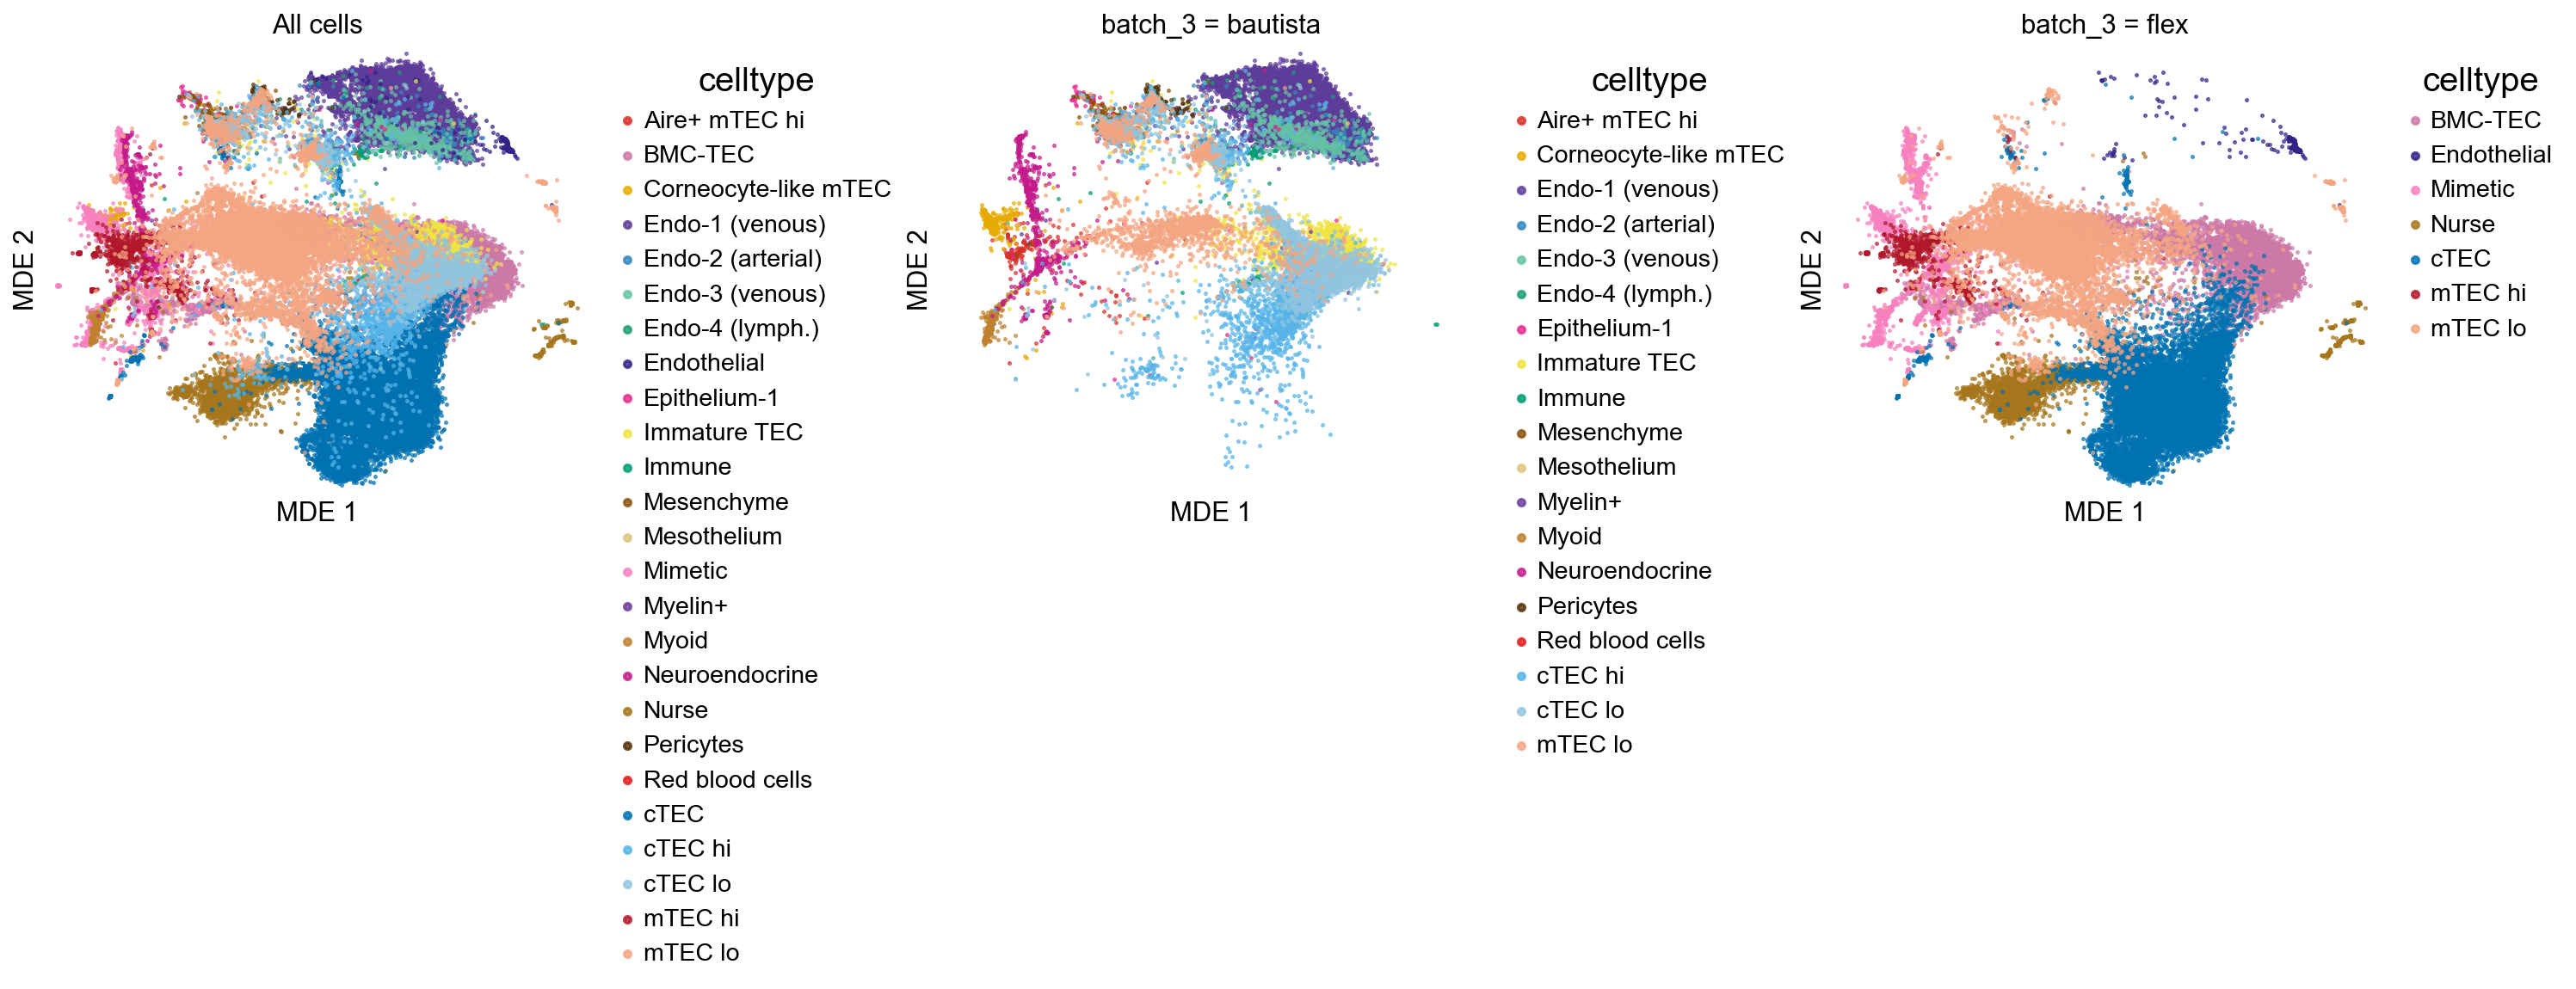

In [159]:

# =========================================================
# Cell-type color map
# =========================================================

celltype_colors = {

    # =====================================================
    # cTEC family
    # =====================================================
    "cTEC": "#0072B2",
    "cTEC hi": "#56B4E9",
    "cTEC lo": "#92C5DE",

    # =====================================================
    # mTEC family
    # =====================================================
    "mTEC hi": "#B2182B",
    "mTEC lo": "#F4A582",
    "Aire+ mTEC hi": "#D73027",

    # =====================================================
    # Other TEC / epithelial
    # =====================================================
    "BMC-TEC": "#CC79A7",
    "Immature TEC": "#F0E442",
    "Corneocyte-like mTEC": "#E6AB02",
    "Mimetic": "#F781BF",
    "Epithelium-1": "#E7298A",
    "Neuroendocrine": "#C51B8A",

    # =====================================================
    # Endothelial family
    # =====================================================
    "Endothelial": "#332288",
    "Endo-1 (venous)": "#5E3C99",
    "Endo-2 (arterial)": "#3288BD",
    "Endo-3 (venous)": "#66C2A5",
    "Endo-4 (lymph.)": "#1B9E77",

    # =====================================================
    # Mesenchymal / stromal
    # =====================================================
    "Mesenchyme": "#8C510A",
    "Myoid": "#BF812D",
    "Mesothelium": "#DFC27D",
    "Pericytes": "#543005",

    # =====================================================
    # Neural
    # =====================================================
    "Myelin+": "#6A3D9A",

    # =====================================================
    # Immune / blood
    # =====================================================
    "Immune": "#009E73",
    "Red blood cells": "#E41A1C",

    # =====================================================
    # Other
    # =====================================================
    "Nurse": "#A6761D",
}


# =========================================================
# Parameters
# =========================================================

basis = SCANVI_MDE_KEY
color_column = "celltype"
batch_column = "batch_3"

output_file = (
    "baut_flex_celltype_by_batch3.pdf"
)

# Size of EACH plotting area
panel_width = 6
panel_height = 6


# =========================================================
# Make sure celltype is categorical
# =========================================================

adata_flex_baut.obs[color_column] = (
    adata_flex_baut.obs[color_column]
    .astype("category")
)


# =========================================================
# Check that all cell types have a defined color
# =========================================================

categories = (
    adata_flex_baut.obs[color_column]
    .cat.categories
)

missing_colors = [
    celltype
    for celltype in categories
    if celltype not in celltype_colors
]

if missing_colors:
    raise ValueError(
        "The following cell types do not have colors "
        f"in celltype_colors:\n{missing_colors}"
    )


# =========================================================
# Create celltype -> color dictionary
#
# Only include cell types actually present in the data
# =========================================================

color_dict = {
    celltype: celltype_colors[celltype]
    for celltype in categories
}


# =========================================================
# Get embedding coordinates from FULL dataset
# =========================================================

embedding = adata_flex_baut.obsm[basis]

x = embedding[:, 0]
y = embedding[:, 1]


# =========================================================
# Fixed limits based on FULL dataset
#
# These limits are used for EVERY panel so that the
# panels can be directly overlaid.
# =========================================================

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_margin = 0.02 * (x_max - x_min)
y_margin = 0.02 * (y_max - y_min)

xlim = (
    x_min - x_margin,
    x_max + x_margin,
)

ylim = (
    y_min - y_margin,
    y_max + y_margin,
)


# =========================================================
# Get batch values
# =========================================================

batch_values = (
    adata_flex_baut.obs[batch_column]
    .dropna()
    .unique()
)

batch_values = sorted(batch_values)


# =========================================================
# All panels
#
# First = full dataset
# Remaining = individual batches
# =========================================================

panel_names = ["All cells"] + [
    f"{batch_column} = {batch}"
    for batch in batch_values
]


# =========================================================
# Number of panels
# =========================================================

n_panels = len(panel_names)


# =========================================================
# Create figure
#
# Each panel gets its own 6 x 6 inch plotting area
# =========================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(
        panel_width * n_panels,
        panel_height,
    ),
)


# Make sure axes is iterable
if n_panels == 1:
    axes = [axes]


# =========================================================
# Plotting function
# =========================================================

def plot_embedding_subset(
    adata,
    ax,
    title,
):

    coords = adata.obsm[basis]

    x = coords[:, 0]
    y = coords[:, 1]

    celltypes = adata.obs[color_column]


    # -----------------------------------------------------
    # Plot cell types
    # -----------------------------------------------------

    for celltype in categories:

        mask = celltypes == celltype

        if mask.sum() == 0:
            continue

        ax.scatter(
            x[mask],
            y[mask],
            s=0.5,
            alpha=0.8,
            color=color_dict[celltype],
            label=celltype,
            rasterized=True,
        )


    # -----------------------------------------------------
    # FIXED coordinate limits
    # -----------------------------------------------------

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


    # -----------------------------------------------------
    # FIXED aspect ratio
    # -----------------------------------------------------

    ax.set_aspect(
        "equal",
        adjustable="box",
    )


    # -----------------------------------------------------
    # Labels
    # -----------------------------------------------------

    ax.set_title(
        title,
        fontsize=14,
    )

    ax.set_xlabel("MDE 1")
    ax.set_ylabel("MDE 2")


    # -----------------------------------------------------
    # Remove grid and ticks
    # -----------------------------------------------------

    ax.grid(False)

    ax.set_xticks([])
    ax.set_yticks([])


    # -----------------------------------------------------
    # Remove spines
    # -----------------------------------------------------

    ax.set_frame_on(False)


    # -----------------------------------------------------
    # Individual legend
    # -----------------------------------------------------

    ax.legend(
        title="celltype",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False,
        markerscale=5,
    )


# =========================================================
# FULL DATASET
# =========================================================

plot_embedding_subset(
    adata=adata_flex_baut,
    ax=axes[0],
    title="All cells",
)


# =========================================================
# INDIVIDUAL BATCHES
# =========================================================

for ax, batch in zip(
    axes[1:],
    batch_values,
):

    mask = (
        adata_flex_baut.obs[batch_column]
        == batch
    )

    adata_batch = adata_flex_baut[
        mask
    ].copy()

    plot_embedding_subset(
        adata=adata_batch,
        ax=ax,
        title=f"{batch_column} = {batch}",
    )


# =========================================================
# Layout
#
# Leave room for the individual legends
# =========================================================

plt.subplots_adjust(
    left=0.04,
    right=0.98,
    bottom=0.08,
    top=0.90,
    wspace=0.65,
)


# =========================================================
# Save
# =========================================================

fig.savefig(
    output_file,
    bbox_inches="tight",
)


# =========================================================
# Display
# =========================================================

plt.show()

## Investigate seurat cluster 8

### Add seurat cluster metadata

In [125]:
adata_flex_baut_new_obs = pd.concat([adata_flex_baut.obs, flex.obs[['seurat_clusters', 'sample.id']].astype('str')], axis = 1)

In [126]:
adata_flex_baut.obs = adata_flex_baut_new_obs.copy()

### Seurat cluster 8 in bautista-flex data

In [130]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_MDE_KEY = "X_scANVI_MDE"

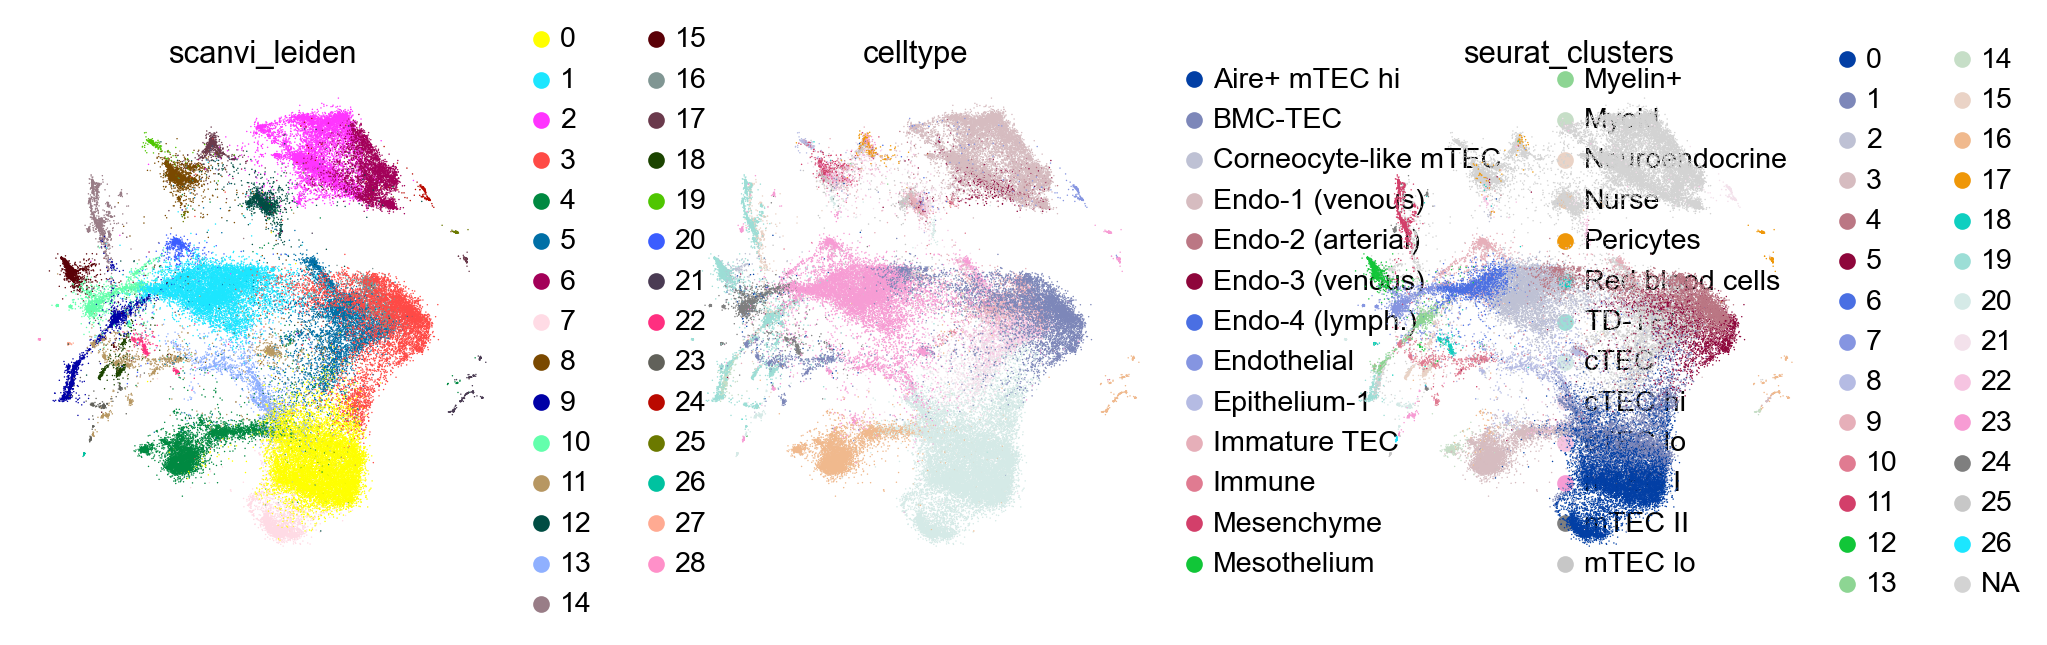

In [131]:
sc.pl.embedding(
    adata_flex_baut,
    basis=SCANVI_MDE_KEY,
    color=["scanvi_leiden", "celltype", "seurat_clusters"],
    ncols=3,
    frameon=False
)

In [134]:
adata_flex_baut[adata_flex_baut.obs['seurat_clusters'] == "8"].obs['scanvi_leiden'].value_counts()

scanvi_leiden
13    708
11    254
1      93
4      71
22     70
5      29
0      22
10     20
7      10
3       9
8       2
6       2
12      2
9       2
16      1
14      1
18      1
20      1
23      1
27      1
Name: count, dtype: int64

In [135]:
adata_flex_baut.obs['scanvi_leiden'].value_counts()

scanvi_leiden
0     11919
1      9115
2      6984
3      6204
4      5625
5      5305
6      3800
7      2239
8      2132
9      1879
10     1846
11     1699
12     1539
13     1532
14     1444
15     1144
16     1125
17     1051
18      562
19      516
20      504
21      382
22      359
23      349
24      197
25      157
26      117
27       76
28       70
Name: count, dtype: int64

In [136]:
# 18,19, 1, 0, 20, 4,7
adata_flex_baut[adata_flex_baut.obs['scanvi_leiden'].isin(['13', '11', '1', '4', '22'])].obs[['scanvi_leiden', 'batch_3']].value_counts()

scanvi_leiden  batch_3 
1              flex        7965
4              flex        5417
11             flex        1627
13             flex        1499
1              bautista    1150
22             flex         348
4              bautista     208
11             bautista      72
13             bautista      33
22             bautista      11
Name: count, dtype: int64

In [137]:
adata_flex_baut.obs['is_eight'] = adata_flex_baut.obs['seurat_clusters'] == "8"
adata_flex_baut.obs['is_thirteen'] = adata_flex_baut.obs['scanvi_leiden'] == "13"

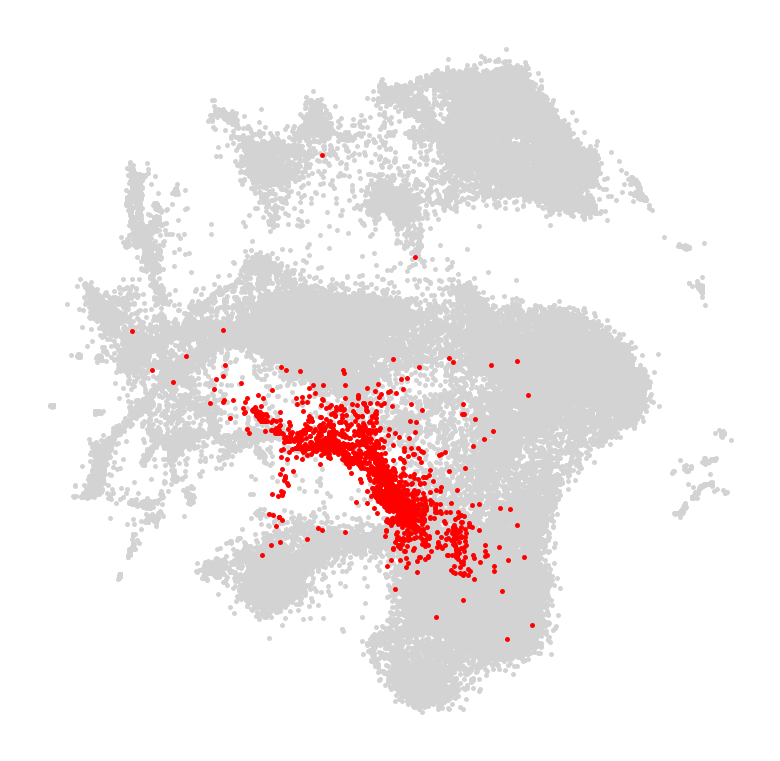

In [138]:
import matplotlib.pyplot as plt

coords = adata_flex_baut.obsm[SCANVI_MDE_KEY]
mask = adata_flex_baut.obs["is_thirteen"]

fig, ax = plt.subplots(figsize=(6, 6))

# Plot background cells first
ax.scatter(
    coords[~mask, 0],
    coords[~mask, 1],
    c="lightgray",
    s=5,
    linewidths=0,
    rasterized=True
)

# Plot highlighted cells second
ax.scatter(
    coords[mask, 0],
    coords[mask, 1],
    c="red",
    s=5,
    linewidths=0,
    rasterized=True
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Save as PDF
fig.savefig(
    "adata_flex_baut_integration_cluster_13.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

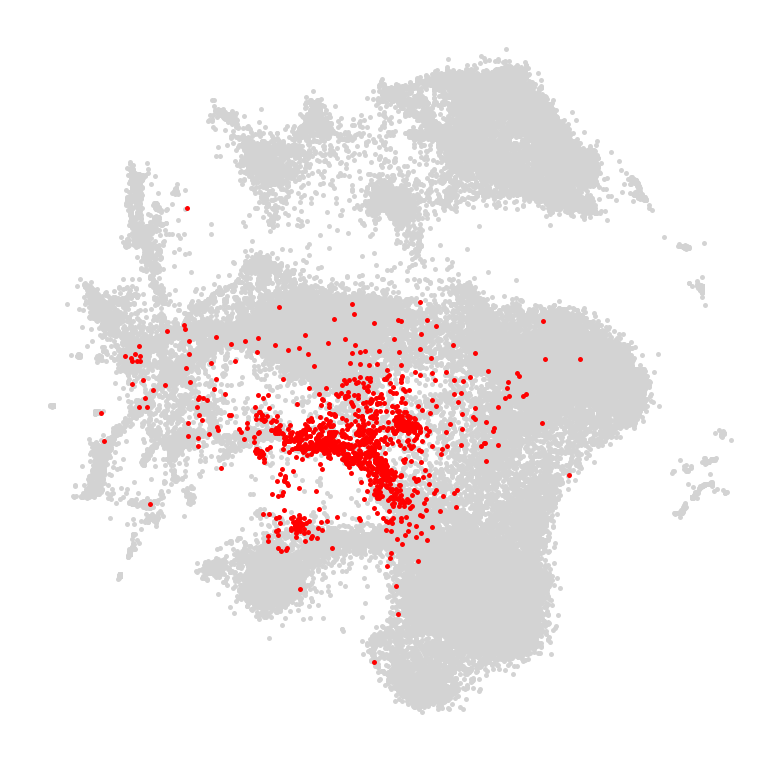

In [139]:
import matplotlib.pyplot as plt

coords = adata_flex_baut.obsm[SCANVI_MDE_KEY]
mask = adata_flex_baut.obs["is_eight"]

fig, ax = plt.subplots(figsize=(6, 6))

# Plot background cells first
ax.scatter(
    coords[~mask, 0],
    coords[~mask, 1],
    c="lightgray",
    s=5,
    linewidths=0,
)

# Plot highlighted cells second
ax.scatter(
    coords[mask, 0],
    coords[mask, 1],
    c="red",
    s=5,
    linewidths=0
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

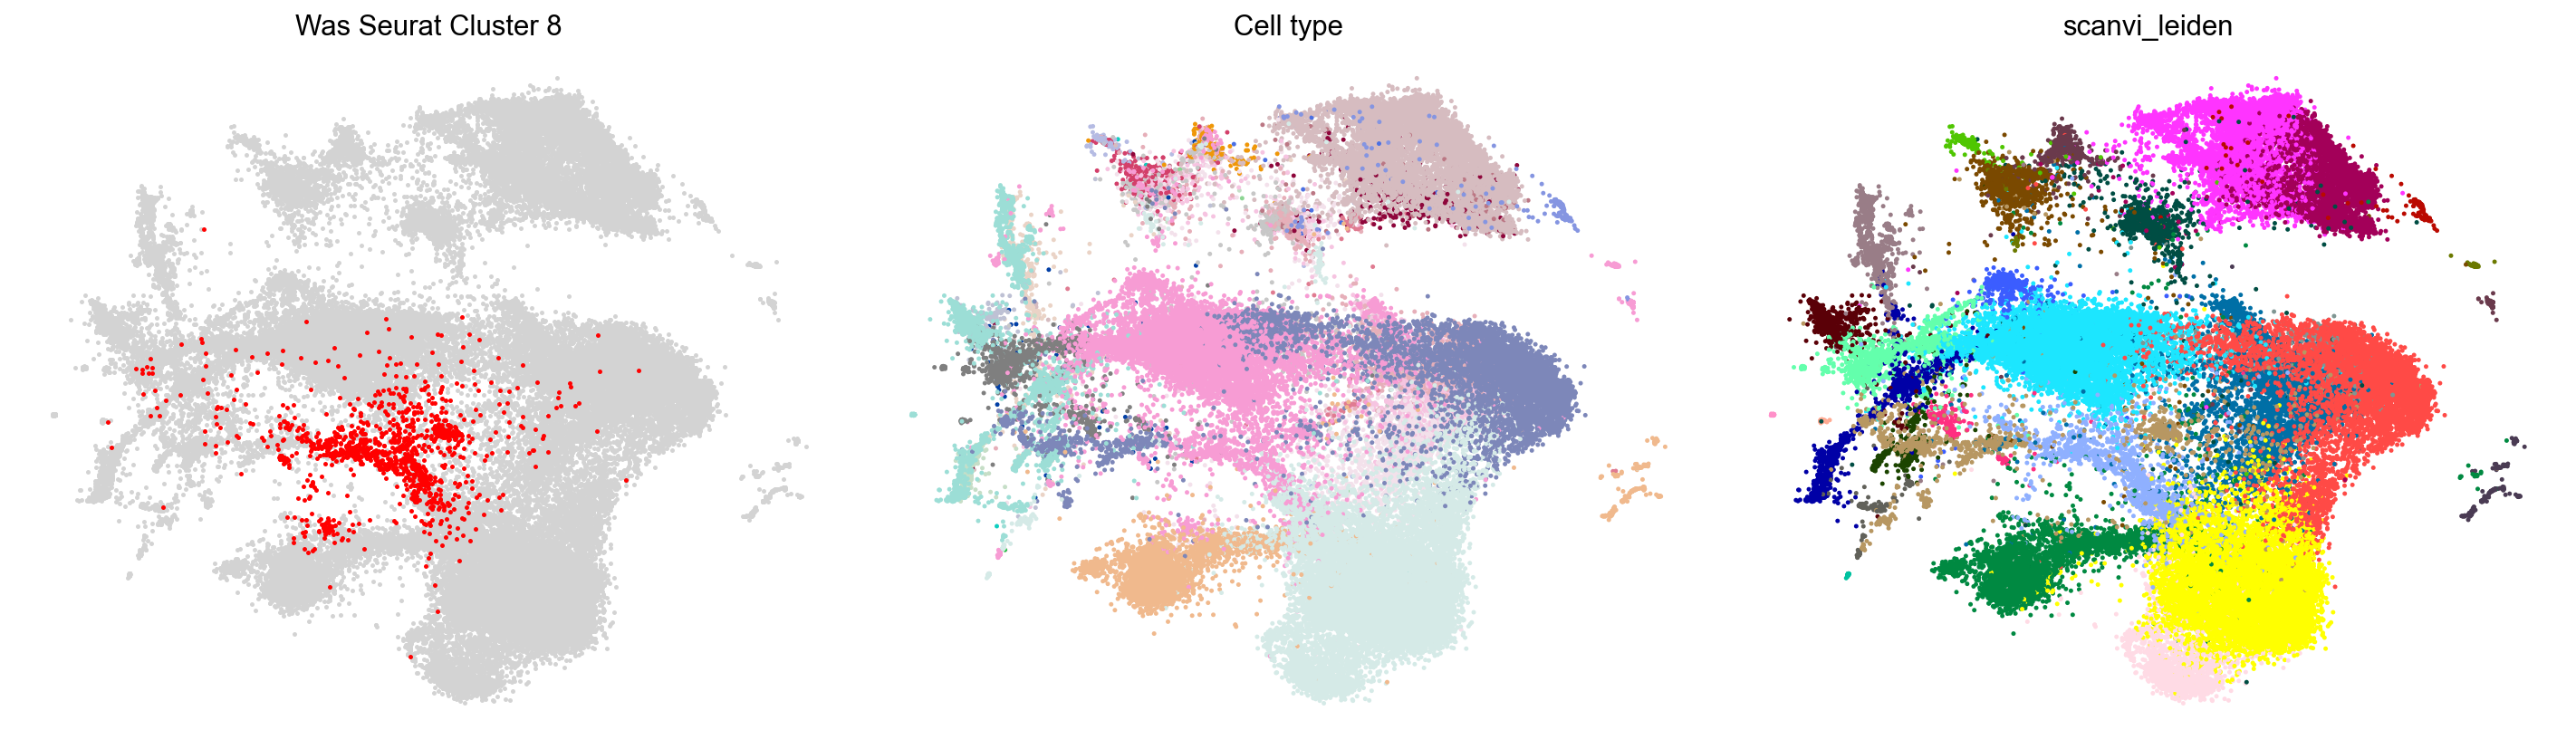

In [141]:
import matplotlib.pyplot as plt

# Embedding coordinates
coords = adata_flex_baut.obsm[SCANVI_MDE_KEY]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------------------------
# Plot 1: Highlight is_eight
# ---------------------------------
mask = adata_flex_baut.obs["is_eight"]

# Plot background cells first
axes[0].scatter(
    coords[~mask, 0],
    coords[~mask, 1],
    c="lightgray",
    s=5,
    linewidths=0,
    rasterized=True,
)

# Plot highlighted cells second
axes[0].scatter(
    coords[mask, 0],
    coords[mask, 1],
    c="red",
    s=5,
    linewidths=0,
    rasterized=True,
)

axes[0].set_title("Was Seurat Cluster 8")

# ---------------------------------
# Plot 2: Cell type
# ---------------------------------
celltypes = adata_flex_baut.obs["celltype"].astype("category")
cell_colors = [
    adata_flex_baut.uns["celltype_colors"][i]
    for i in celltypes.cat.codes
]

axes[1].scatter(
    coords[:, 0],
    coords[:, 1],
    c=cell_colors,
    s=5,
    linewidths=0,
    rasterized=True,
)

axes[1].set_title("Cell type")

# ---------------------------------
# Plot 3: scanvi_leiden
# ---------------------------------
clusters = adata_flex_baut.obs["scanvi_leiden"].astype("category")
cluster_colors = [
    adata_flex_baut.uns["scanvi_leiden_colors"][i]
    for i in clusters.cat.codes
]

axes[2].scatter(
    coords[:, 0],
    coords[:, 1],
    c=cluster_colors,
    s=5,
    linewidths=0,
    rasterized=True,
)

axes[2].set_title("scanvi_leiden")

# ---------------------------------
# Formatting
# ---------------------------------
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()